$
\def\D{\Omega}
\def\ipar{m}
\def\R{\mathbb{R}}
\def\del{\partial}
\def\vec{\bf}
\def\priorm{\mu_0}
\def\C{\mathcal{C}}
\def\Acal{\mathcal{A}}
\def\postm{\mu_{\rm{post}}}
\def\iparpost{\ipar_\text{post}}
\def\obs{ {\vec d}} 
\def\yobs{\obs^{\text{obs}}}
\def\obsop{\mathcal{B}}
\def\dd{\vec{\bar{d}}}
\def\iFF{\mathcal{F}}
\def\iFFadj{\mathcal{F}^*}
\def\ncov{\Gamma_{\mathrm{noise}}}
$
# Bayesian initial condition inversion in an advection-diffusion problem 

In this example we tackle the problem of quantifying the uncertainty in the solution of an inverse problem governed by a parabolic PDE via the Bayesian inference framework. The underlying PDE is a time-dependent advection-diffusion equation in which we seek to infer an unknown initial condition from spatio-temporal point measurements.

### The Bayesian inverse problem:

Following the Bayesian framework, we utilize 
a Gaussian prior measure $\priorm = \mathcal{N}(\ipar_0,\C_0)$,
with $\C_0=\Acal^{-2}$ where $\Acal$ is an elliptic differential operator as 
described in the PoissonBayesian example, and use an additive
Gaussian noise model. Therefore, the solution of the Bayesian inverse
problem is the posterior measure, $\postm = \mathcal{N}(\iparpost,\C_\text{post})$ with
$\iparpost$ and $\C_\text{post}$.

- The posterior mean $\iparpost$ is characterized as the minimizer of

$$
\begin{aligned}
& \mathcal{J}(\ipar) :=
  \frac{1}{2} \left\| \obsop u(\ipar) -\obs  \right\|^2_{\ncov^{-1}}
  + \frac 12 \left\| \Acal(\ipar - \ipar_0 \right)\|^2_{L^2(\D)},
\end{aligned}
$$

which can also be interpreted as the regularized functional to be
minimized in deterministic inversion. The observation operator $\mathcal{B}$ extracts the values of the forward solution $u$ on a set of
locations $\{{\vec{x}}_1, \ldots, {\vec{x}}_n\} \subset \D$ at
times $\{t_1, \ldots, t_N\} \subset [0, T]$.

- The posterior covariance $\C_{\text{post}}$ is the inverse of the Hessian of $\mathcal{J}(\ipar)$, i.e.,

$$
\C_{\text{post}} = (\iFFadj \ncov^{-1} \iFF + \C_0^{-1})^{-1}.
$$


### The forward problem:

The parameter-to-observable map $\iFF \,\ipar := \obsop\, u(\ipar)$ maps an initial condition $\ipar \in L^2(\D)$ to pointwise spatiotemporal observations of the concentration field $u({\vec x},t)$ through solution of the advection-diffusion equation given by

$$
\begin{split}
u_t - \kappa\Delta u + {\vec v} \cdot \nabla u &= 0     & \quad \text{in } \D\times(0,T),\\
                                 u(\cdot, 0) &= \ipar & \quad \text{in } \D,\\
                \kappa \nabla u\cdot {\vec{n}} &= 0     & \quad \text{on } \partial\D \times (0,T).
\end{split}
$$

Here, $\D \subset \R^d$ ($d \in \{2, 3\}$) is a bounded domain, $\kappa > 0$ is the diffusion coefficient and $T > 0$ is the final
time. The velocity field
$\vec{v}$ is computed by solving the following steady-state
Navier-Stokes equation with the side walls driving the flow:

$$
\begin{aligned}
- \frac{1}{\operatorname{Re}} \Delta {\vec v} + \nabla q + {\vec v} \cdot \nabla {\vec v} &= 0 &\quad&\text{ in }\D,\\
\nabla \cdot {\vec v} &= 0 &&\text{ in }\D,\\
{\vec v} &= {\vec g} &&\text{ on } \partial\D.
\end{aligned}
$$

Here, $q$ is pressure, $\text{Re}$ is the Reynolds number. The Dirichlet boundary data
${\vec g} \in \R^d$ is given by 
${\vec g} = {\vec e}_2$ on the left wall of the domain, 
${\vec g}=-{\vec e}_2$ on the right wall,  and ${\vec g} = {\vec 0}$ everywhere else.

### The adjoint problem:

The adjoint problem is a final value problem, since $p$ is specified at $t = T$ rather than at $t = 0$. Thus, it is solved backwards in time, which amounts to the solution of the advection-diffusion equation

$$
\begin{aligned}
-p_t - \nabla \cdot (p {\vec v}) - \kappa \Delta p  &= -\obsop^* (\obsop u - \obs) & \quad &\text{ in } \D\times (0,T),\\
                                      p(\cdot, T) &= 0             &       &\text{ in } \D,\\ 
({ \vec{v} }p+\kappa\nabla p)\cdot {\vec{n}}            &= 0             &       &\text{ on } \partial\D\times (0,T).
\end{aligned}
$$

Then, the adjoint of the parameter to observable map $\iFF^*$ is defined by setting $\iFF^*\obs = p({\vec x}, 0).$

## 1. Load modules

In [1]:
import dolfin as dl
#import ufl
import math
import numpy as np
import matplotlib.pyplot as plt
#import scipy.optimize as opt
import nlopt
%matplotlib inline
import sys
import os
sys.path.append( os.environ.get('HIPPYLIB_BASE_DIR', "../") )
sys.path.insert(1, '/mnt/c/Users/Sonia/Documents/Courant/Research/INLA/hippylib')
from hippylib import *
sys.path.append( os.environ.get('HIPPYLIB_BASE_DIR', "..") + "/applications/ad_diff/" )
from model_ad_diff import SpaceTimePointwiseStateObservation
# modified hippylib code (makes kappa no longer hardcoded)
from model_ad_diff_modified import TimeDependentAD
#from posterior_modified import *

import logging
logging.getLogger('FFC').setLevel(logging.WARNING)
#logging.getLogger('UFL').setLevel(logging.WARNING)
dl.set_log_active(False)

import time
import line_profiler
%load_ext line_profiler

In [3]:
# # from ..algorithms.linalg import MatMatMult, get_diagonal, amg_method, estimate_diagonal_inv2, Solver2Operator, Operator2Solver
# # from ..algorithms.linSolvers import PETScKrylovSolver
# # from ..algorithms.traceEstimator import TraceEstimator
# # from ..algorithms.multivector import MultiVector
# # from ..algorithms.randomizedEigensolver import doublePass, doublePassG

# # from ..utils.random import parRandom
# # from ..utils.vector2function import vector2Function

# # from .expression import ExpressionModule
# import numbers

# class _Prior:
#     """
#     Abstract class to describe the prior model.
#     Concrete instances of a :code:`_Prior class` should expose
#     the following attributes and methods.
    
#     Attributes:

#     - :code:`R`:       an operator to apply the regularization/precision operator.
#     - :code:`Rsolver`: an operator to apply the inverse of the regularization/precision operator.
#     - :code:`M`:       the mass matrix in the control space.
#     - :code:`mean`:    the prior mean.
    
#     Methods:

#     - :code:`init_vector(self,x,dim)`: Inizialize a vector :code:`x` to be compatible with the range/domain of :code:`R`
#       If :code:`dim == "noise"` inizialize :code:`x` to be compatible with the size of
#       white noise used for sampling.
      
#     - :code:`sample(self, noise, s, add_mean=True)`: Given :code:`noise` :math:`\\sim \\mathcal{N}(0, I)` compute a sample s from the prior.
#       If :code:`add_mean==True` add the prior mean value to :code:`s`.
#     """ 
               
#     def trace(self, method="Exact", tol=1e-1, min_iter=20, max_iter=100, r = 200):
#         """
#         Compute/estimate the trace of the prior covariance operator.
        
#         - If :code:`method=="Exact"` we compute the trace exactly by summing the diagonal entries of :math:`R^{-1}M`.
#           This requires to solve :math:`n` linear system in :math:`R` (not scalable, but ok for illustration purposes).
          
#         - If :code:`method=="Estimator"` use the trace estimator algorithms implemeted in the class :code:`TraceEstimator`.
#           :code:`tol` is a relative bound on the estimator standard deviation. In particular, we used enough samples in the
#           Estimator such that the standard deviation of the estimator is less then :code:`tol`:math:`tr(\\mbox{Prior})`.
#           :code:`min_iter` and :code:`max_iter` are the lower and upper bound on the number of samples to be used for the
#           estimation of the trace. 
#         """
#         op = _RinvM(self.Rsolver, self.M)
#         if method == "Exact":
#             marginal_variance = dl.Vector(self.R.mpi_comm())
#             self.init_vector(marginal_variance,0)
#             get_diagonal(op, marginal_variance)
#             return marginal_variance.sum()
#         elif method == "Estimator":
#             tr_estimator = TraceEstimator(op, False, tol)
#             tr_exp, tr_var = tr_estimator(min_iter, max_iter)
#             return tr_exp
#         elif method == "Randomized":
#             dummy = dl.Vector(self.R.mpi_comm())
#             self.init_vector(dummy,0)
#             Omega = MultiVector(dummy, r)
#             parRandom.normal(1., Omega)
#             d, _ = doublePassG(Solver2Operator(self.Rsolver),
#                                Solver2Operator(self.Msolver),
#                                Operator2Solver(self.M),
#                                Omega, r, s = 1, check = False )
#             return d.sum()
#         else:
#             raise NameError("Unknown method")
        
#     def pointwise_variance(self, method, k = 1000000, r = 200):
#         """
#         Compute/estimate the prior pointwise variance.
        
#         - If :code:`method=="Exact"` we compute the diagonal entries of :math:`R^{-1}` entry by entry. 
#           This requires to solve :math:`n` linear system in :math:`R` (not scalable, but ok for illustration purposes).
#         """
#         pw_var = dl.Vector(self.R.mpi_comm())
#         self.init_vector(pw_var,0)
#         if method == "Exact":
#             get_diagonal(Solver2Operator(self.Rsolver, init_vector=self.init_vector), pw_var)
#         elif method == "Estimator":
#             estimate_diagonal_inv2(self.Rsolver, k, pw_var)
#         elif method == "Randomized":
#             Omega = MultiVector(pw_var, r)
#             parRandom.normal(1., Omega)
#             d, U = doublePass(Solver2Operator(self.Rsolver),
#                                Omega, r, s = 1, check = False )
            
#             for i in np.arange(U.nvec()):
#                 pw_var.axpy(d[i], U[i]*U[i])
#         else:
#             raise NameError("Unknown method")
        
#         return pw_var
        
#     def cost(self,m):
#         d = self.mean.copy()
#         d.axpy(-1., m)
#         Rd = dl.Vector(self.R.mpi_comm())
#         self.init_vector(Rd,0)
#         self.R.mult(d,Rd)
#         return .5*Rd.inner(d)
    
#     def grad(self,m, out):
#         d = m.copy()
#         d.axpy(-1., self.mean)
#         self.R.mult(d,out)

#     def init_vector(self,x,dim):
#         raise NotImplementedError("Child class should implement method init_vector")

#     def sample(self, noise, s, add_mean=True):
#         raise NotImplementedError("Child class should implement method sample")

#     def getHessianPreconditioner(self):
#         " Return the preconditioner for Newton-CG "
#         return self.Rsolver
        

# class _BilaplacianR:
#     """
#     Operator that represent the action of the regularization/precision matrix
#     for the Bilaplacian prior.
#     """
#     def __init__(self, A, Msolver):
#         self.A = A
#         self.Msolver = Msolver

#         self.help1, self.help2 = dl.Vector(self.A.mpi_comm()), dl.Vector(self.A.mpi_comm())
#         self.A.init_vector(self.help1, 0)
#         self.A.init_vector(self.help2, 1)
        
#     def init_vector(self,x, dim):
#         self.A.init_vector(x,1)
        
#     def mpi_comm(self):
#         return self.A.mpi_comm()
        
#     def mult(self,x,y):
#         self.A.mult(x, self.help1)
#         self.Msolver.solve(self.help2, self.help1)
#         self.A.mult(self.help2, y)
        
# class _BilaplacianRsolver():
#     """
#     Operator that represent the action of the inverse the regularization/precision matrix
#     for the Bilaplacian prior.
#     """
#     def __init__(self, Asolver, M):
#         self.Asolver = Asolver
#         self.M = M
        
#         self.help1, self.help2 = dl.Vector(self.M.mpi_comm()), dl.Vector(self.M.mpi_comm())
#         self.init_vector(self.help1, 0)
#         self.init_vector(self.help2, 0)
        
#     def init_vector(self,x, dim):
#         self.M.init_vector(x,1)
        
#     def solve(self,x,b):
#         nit = self.Asolver.solve(self.help1, b)
#         self.M.mult(self.help1, self.help2)
#         nit += self.Asolver.solve(x, self.help2)
#         return nit

# class SqrtPrecisionPDE_Prior(_Prior):
#     """
#     This class implement a prior model with covariance matrix
#     :math:`C = A^{-1} M A^-1`,
#     where A is the finite element matrix arising from discretization of sqrt_precision_varf_handler
    
#     """
    
#     def __init__(self, Vh, sqrt_precision_varf_handler, mean=None, rel_tol=1e-12, max_iter=1000):
#         """
#         Construct the prior model.
#         Input:

#         - :code:`Vh`:              the finite element space for the parameter
#         - :code:sqrt_precision_varf_handler: the PDE representation of the  sqrt of the covariance operator
#         - :code:`mean`:            the prior mean
#         """

#         self.Vh = Vh
        
#         trial = dl.TrialFunction(Vh)
#         test  = dl.TestFunction(Vh)
        
#         varfM = dl.inner(trial,test)*dl.dx       
#         self.M = dl.assemble(varfM)
#         self.Msolver = PETScKrylovSolver(self.Vh.mesh().mpi_comm(), "cg", "jacobi")
#         self.Msolver.set_operator(self.M)
#         self.Msolver.parameters["maximum_iterations"] = max_iter
#         self.Msolver.parameters["relative_tolerance"] = rel_tol
#         self.Msolver.parameters["error_on_nonconvergence"] = True
#         self.Msolver.parameters["nonzero_initial_guess"] = False
        
#         self.A = dl.assemble( sqrt_precision_varf_handler(trial, test) )    
#         self.Asolver = PETScLUSolver( self.Vh.mesh().mpi_comm() ) # *** CHANGED SOLVER TO LU ***
#         self.Asolver.set_operator( dl.as_backend_type(self.A) )
# #         self.Asolver = PETScKrylovSolver(self.Vh.mesh().mpi_comm(), "cg", amg_method())
# #         self.Asolver.set_operator(self.A)
# #         self.Asolver.parameters["maximum_iterations"] = max_iter
# #         self.Asolver.parameters["relative_tolerance"] = rel_tol
# #         self.Asolver.parameters["error_on_nonconvergence"] = True
# #         self.Asolver.parameters["nonzero_initial_guess"] = False
        
#         old_qr = dl.parameters["form_compiler"]["quadrature_degree"]
#         dl.parameters["form_compiler"]["quadrature_degree"] = -1
#         qdegree = 2*Vh._ufl_element.degree()
#         metadata = {"quadrature_degree" : qdegree}


#         representation_old = dl.parameters["form_compiler"]["representation"]
#         dl.parameters["form_compiler"]["representation"] = "quadrature"
            
#         num_sub_spaces = Vh.num_sub_spaces()
#         if num_sub_spaces <= 1: #SCALAR PARAMETER
#             element = dl.FiniteElement("Quadrature", Vh.mesh().ufl_cell(), qdegree, quad_scheme="default")
#         else: #Vector FIELD PARAMETER
#             element = dl.VectorElement("Quadrature", Vh.mesh().ufl_cell(),
#                                        qdegree, dim=num_sub_spaces, quad_scheme="default")
#         Qh = dl.FunctionSpace(Vh.mesh(), element)
            
#         ph = dl.TrialFunction(Qh)
#         qh = dl.TestFunction(Qh)
#         Mqh = dl.assemble(dl.inner(ph,qh)*dl.dx(metadata=metadata))
#         if num_sub_spaces <= 1:
#             one_constant = dl.Constant(1.)
#         else:
#             one_constant = dl.Constant( tuple( [1.]*num_sub_spaces) )
#         ones = dl.interpolate(one_constant, Qh).vector()
#         dMqh = Mqh*ones
#         Mqh.zero()
#         dMqh.set_local( ones.get_local() / np.sqrt(dMqh.get_local() ) )
#         Mqh.set_diagonal(dMqh)
#         MixedM = dl.assemble(dl.inner(ph,test)*dl.dx(metadata=metadata))
#         self.sqrtM = MatMatMult(MixedM, Mqh)

#         dl.parameters["form_compiler"]["quadrature_degree"] = old_qr
#         dl.parameters["form_compiler"]["representation"] = representation_old
                             
#         self.R = _BilaplacianR(self.A, self.Msolver)      
#         self.Rsolver = _BilaplacianRsolver(self.Asolver, self.M)
         
#         self.mean = mean
        
#         if self.mean is None:
#             self.mean = dl.Vector(self.R.mpi_comm())
#             self.init_vector(self.mean, 0)
     
#     def init_vector(self,x,dim):
#         """
#         Inizialize a vector :code:`x` to be compatible with the range/domain of :math:`R`.

#         If :code:`dim == "noise"` inizialize :code:`x` to be compatible with the size of
#         white noise used for sampling.
#         """
#         if dim == "noise":
#             self.sqrtM.init_vector(x, 1)
#         else:
#             self.A.init_vector(x,dim)   
        
#     def sample(self, noise, s, add_mean=True):
#         """
#         Given :code:`noise` :math:`\\sim \\mathcal{N}(0, I)` compute a sample :code:`s` from the prior.

#         If :code:`add_mean == True` add the prior mean value to :code:`s`.
#         """
#         rhs = self.sqrtM*noise
#         self.Asolver.solve(s, rhs)
        
#         if add_mean:
#             s.axpy(1., self.mean)
            
# def BiLaplacianPrior(Vh, gamma, delta, Theta = None, mean=None, rel_tol=1e-12, max_iter=1000, robin_bc=False):
#     """
#     This function construct an instance of :code"`SqrtPrecisionPDE_Prior`  with covariance matrix
#     :math:`C = (\\delta I + \\gamma \\mbox{div } \\Theta \\nabla) ^ {-2}`.
    
#     The magnitude of :math:`\\delta\\gamma` governs the variance of the samples, while
#     the ratio :math:`\\frac{\\gamma}{\\delta}` governs the correlation lenght.
    
#     Here :math:`\\Theta` is a SPD tensor that models anisotropy in the covariance kernel.
    
#     Input:

#     - :code:`Vh`:              the finite element space for the parameter
#     - :code:`gamma` and :code:`delta`: the coefficient in the PDE (floats, dl.Constant, dl.Expression, or dl.Function)
#     - :code:`Theta`:           the SPD tensor for anisotropic diffusion of the PDE
#     - :code:`mean`:            the prior mean
#     - :code:`rel_tol`:         relative tolerance for solving linear systems involving covariance matrix
#     - :code:`max_iter`:        maximum number of iterations for solving linear systems involving covariance matrix
#     - :code:`robin_bc`:        whether to use Robin boundary condition to remove boundary artifacts
#     """
#     if isinstance(gamma, numbers.Number):
#         gamma = dl.Constant(gamma)
        
#     if isinstance(delta, numbers.Number):
#         delta = dl.Constant(delta)

    
#     def sqrt_precision_varf_handler(trial, test): 
#         if Theta == None:
#             varfL = dl.inner(dl.grad(trial), dl.grad(test))*dl.dx
#         else:
#             varfL = dl.inner( Theta*dl.grad(trial), dl.grad(test))*dl.dx
        
#         varfM = dl.inner(trial,test)*dl.dx
        
#         varf_robin = dl.inner(trial,test)*dl.ds
        
#         if robin_bc:
#             robin_coeff = gamma*dl.sqrt(delta/gamma)/dl.Constant(1.42)
#         else:
#             robin_coeff = dl.Constant(0.)
        
#         return gamma*varfL + delta*varfM + robin_coeff*varf_robin
    
#     return SqrtPrecisionPDE_Prior(Vh, sqrt_precision_varf_handler, mean, rel_tol, max_iter)


In [4]:
# # added to replace ufl.min_value
# def Min(a, b): return (a+b-abs(a-b))/dl.Constant(2)

# class TimeDependentAD:    
#     def __init__(self, mesh, Vh, prior, misfit, simulation_times, diffusivity, wind_velocity, gls_stab):
#         self.mesh = mesh
#         self.Vh = Vh
#         self.prior = prior
#         self.misfit = misfit
#         # Assume constant timestepping
#         self.simulation_times = simulation_times
#         dt = simulation_times[1] - simulation_times[0]


#         u = dl.TrialFunction(Vh[STATE])
#         v = dl.TestFunction(Vh[STATE])
        
#         #kappa = dl.Constant(.001)
#         kappa = dl.Constant(diffusivity)
#         dt_expr = dl.Constant(dt)
        
#         r_trial = u + dt_expr*( -dl.div(kappa*dl.grad(u))+ dl.inner(wind_velocity, dl.grad(u)) )
#         r_test  = v + dt_expr*( -dl.div(kappa*dl.grad(v))+ dl.inner(wind_velocity, dl.grad(v)) )

        
#         h = dl.CellDiameter(mesh)
#         vnorm = dl.sqrt(dl.inner(wind_velocity, wind_velocity))
#         if gls_stab:
#             tau = Min((h*h)/(dl.Constant(2.)*kappa), h/vnorm )
#         else:
#             tau = dl.Constant(0.)
                            
#         self.M = dl.assemble( dl.inner(u,v)*dl.dx )
#         self.M_stab = dl.assemble( dl.inner(u, v+tau*r_test)*dl.dx )
#         self.Mt_stab = dl.assemble( dl.inner(u+tau*r_trial,v)*dl.dx )
#         Nvarf  = (dl.inner(kappa * dl.grad(u), dl.grad(v)) + dl.inner(wind_velocity, dl.grad(u))*v )*dl.dx
#         Ntvarf  = (dl.inner(kappa *dl.grad(v), dl.grad(u)) + dl.inner(wind_velocity, dl.grad(v))*u )*dl.dx
#         self.N  = dl.assemble( Nvarf )
#         self.Nt = dl.assemble(Ntvarf)
#         stab = dl.assemble( tau*dl.inner(r_trial, r_test)*dl.dx)
#         self.L = self.M + dt*self.N + stab
#         self.Lt = self.M + dt*self.Nt + stab
        
#         self.solver  = PETScLUSolver( self.mesh.mpi_comm() )
#         self.solver.set_operator( dl.as_backend_type(self.L) )
#         self.solvert = PETScLUSolver( self.mesh.mpi_comm() ) 
#         self.solvert.set_operator(dl.as_backend_type(self.Lt) )
                        
#         # Part of model public API
#         self.gauss_newton_approx = False
                    
#     def generate_vector(self, component = "ALL"):
#         if component == "ALL":
#             u = TimeDependentVector(self.simulation_times)
#             u.initialize(self.M, 0)
#             m = dl.Vector()
#             self.prior.init_vector(m,0)
#             p = TimeDependentVector(self.simulation_times)
#             p.initialize(self.M, 0)
#             return [u, m, p]
#         elif component == STATE:
#             u = TimeDependentVector(self.simulation_times)
#             u.initialize(self.M, 0)
#             return u
#         elif component == PARAMETER:
#             m = dl.Vector()
#             self.prior.init_vector(m,0)
#             return m
#         elif component == ADJOINT:
#             p = TimeDependentVector(self.simulation_times)
#             p.initialize(self.M, 0)
#             return p
#         else:
#             raise
    
#     def init_parameter(self, m):
#         self.prior.init_vector(m,0)
        
          
#     def cost(self, x):
#         Rdx = dl.Vector()
#         self.prior.init_vector(Rdx,0)
#         dx = x[PARAMETER] - self.prior.mean
#         self.prior.R.mult(dx, Rdx)
#         reg = .5*Rdx.inner(dx)
        
#         misfit = self.misfit.cost(x)
                
#         return [reg+misfit, reg, misfit]
    
#     def solveFwd(self, out, x):
#         out.zero()
#         uold = x[PARAMETER]
#         u = dl.Vector()
#         rhs = dl.Vector()
#         self.M.init_vector(rhs, 0)
#         self.M.init_vector(u, 0)
#         for t in self.simulation_times[1::]:
#             self.M_stab.mult(uold, rhs)
#             self.solver.solve(u, rhs)
#             out.store(u,t)
#             uold = u
    
#     def solveAdj(self, out, x):
        
#         grad_state = TimeDependentVector(self.simulation_times)
#         grad_state.initialize(self.M, 0)
#         self.misfit.grad(STATE, x, grad_state)
        
#         out.zero()
        
#         pold = dl.Vector()
#         self.M.init_vector(pold,0)
            
#         p = dl.Vector()
#         self.M.init_vector(p,0)
        
#         rhs = dl.Vector()
#         self.M.init_vector(rhs,0)
        
#         grad_state_snap = dl.Vector()
#         self.M.init_vector(grad_state_snap,0)

          
#         for t in self.simulation_times[::-1]:
#             self.Mt_stab.mult(pold,rhs)
#             grad_state.retrieve(grad_state_snap, t)
#             rhs.axpy(-1., grad_state_snap)
#             self.solvert.solve(p, rhs)
#             pold = p
#             out.store(p, t)            
            
#     def evalGradientParameter(self,x, mg, misfit_only=False):
#         self.prior.init_vector(mg,1)
#         if misfit_only == False:
#             dm = x[PARAMETER] - self.prior.mean
#             self.prior.R.mult(dm, mg)
#         else:
#             mg.zero()
        
#         p0 = dl.Vector()
#         self.M.init_vector(p0,0)
#         x[ADJOINT].retrieve(p0, self.simulation_times[1])
        
#         mg.axpy(-1., self.Mt_stab*p0)
        
#         g = dl.Vector()
#         self.M.init_vector(g,1)
        
#         self.prior.Msolver.solve(g,mg)
        
#         grad_norm = g.inner(mg)
        
#         return grad_norm
        
    
#     def setPointForHessianEvaluations(self, x, gauss_newton_approx=False):
#         """
#         Specify the point x = [u,a,p] at which the Hessian operator (or the Gauss-Newton approximation)
#         need to be evaluated.
        
#         Nothing to do since the problem is linear
#         """
#         self.gauss_newton_approx = gauss_newton_approx
#         return

        
#     def solveFwdIncremental(self, sol, rhs):
#         sol.zero()
#         uold = dl.Vector()
#         u = dl.Vector()
#         Muold = dl.Vector()
#         myrhs = dl.Vector()
#         self.M.init_vector(uold, 0)
#         self.M.init_vector(u, 0)
#         self.M.init_vector(Muold, 0)
#         self.M.init_vector(myrhs, 0)

#         for t in self.simulation_times[1::]:
#             self.M_stab.mult(uold, Muold)
#             rhs.retrieve(myrhs, t)
#             myrhs.axpy(1., Muold)
#             self.solver.solve(u, myrhs)
#             sol.store(u,t)
#             uold = u


        
#     def solveAdjIncremental(self, sol, rhs):
#         sol.zero()
#         pold = dl.Vector()
#         p = dl.Vector()
#         Mpold = dl.Vector()
#         myrhs = dl.Vector()
#         self.M.init_vector(pold, 0)
#         self.M.init_vector(p, 0)
#         self.M.init_vector(Mpold, 0)
#         self.M.init_vector(myrhs, 0)

#         for t in self.simulation_times[::-1]:
#             self.Mt_stab.mult(pold,Mpold)
#             rhs.retrieve(myrhs, t)
#             Mpold.axpy(1., myrhs)
#             self.solvert.solve(p, Mpold)
#             pold = p
#             sol.store(p, t)  
            
    
#     def applyC(self, dm, out):
#         out.zero()
#         myout = dl.Vector()
#         self.M.init_vector(myout, 0)
#         self.M_stab.mult(dm,myout)
#         myout *= -1.
#         t = self.simulation_times[1]
#         out.store(myout,t)
        
#         myout.zero()
#         for t in self.simulation_times[2:]:
#             out.store(myout,t)
    
#     def applyCt(self, dp, out):
#         t = self.simulation_times[1]
#         dp0 = dl.Vector()
#         self.M.init_vector(dp0,0)
#         dp.retrieve(dp0, t)
#         dp0 *= -1.
#         self.Mt_stab.mult(dp0, out)

    
#     def applyWuu(self, du, out):
#         out.zero()
#         self.misfit.apply_ij(STATE, STATE, du, out)

    
#     def applyWum(self, dm, out):
#         out.zero()

    
#     def applyWmu(self, du, out):
#         out.zero()
    
#     def applyR(self, dm, out):
#         self.prior.R.mult(dm,out)
    
#     def applyWmm(self, dm, out):
#         out.zero()
        
#     def exportState(self, x, filename, varname):
#         out_file = dl.XDMFFile(self.Vh[STATE].mesh().mpi_comm(), filename)
#         out_file.parameters["functions_share_mesh"] = True
#         out_file.parameters["rewrite_function_mesh"] = False
#         ufunc = dl.Function(self.Vh[STATE], name=varname)
#         t = self.simulation_times[0]
#         out_file.write(vector2Function(x[PARAMETER], self.Vh[STATE], name=varname),t)
#         for t in self.simulation_times[1:]:
#             x[STATE].retrieve(ufunc.vector(), t)
#             out_file.write(ufunc, t)

## 2. Construct the velocity field

In [5]:
# All from original AdvectionDiffusionBayesian tutorial
def v_boundary(x,on_boundary):
    return on_boundary

def q_boundary(x,on_boundary):
    return x[0] < dl.DOLFIN_EPS and x[1] < dl.DOLFIN_EPS
        
def computeVelocityField(mesh):
    Xh = dl.VectorFunctionSpace(mesh,'Lagrange', 2)
    Wh = dl.FunctionSpace(mesh, 'Lagrange', 1)
    mixed_element = dl.MixedElement([Xh.ufl_element(), Wh.ufl_element()])
    XW = dl.FunctionSpace(mesh, mixed_element)

    Re = dl.Constant(1e2)
    
    g = dl.Expression(('0.0','(x[0] < 1e-14) - (x[0] > 1 - 1e-14)'), degree=1)
    bc1 = dl.DirichletBC(XW.sub(0), g, v_boundary)
    
    bc2 = dl.DirichletBC(XW.sub(1), dl.Constant(0), q_boundary, 'pointwise')
    bcs = [bc1, bc2]
    
    vq = dl.Function(XW)
    (v,q) = dl.split(vq)
    (v_test, q_test) = dl.TestFunctions (XW)
    
    def strain(v):
        return dl.sym(dl.grad(v))
    
    F = ( (2./Re)*dl.inner(strain(v),strain(v_test))+ dl.inner (dl.nabla_grad(v)*v, v_test)
           - (q * dl.div(v_test)) + ( dl.div(v) * q_test) ) * dl.dx
           
    dl.solve(F == 0, vq, bcs, solver_parameters={"newton_solver":
                                         {"relative_tolerance":1e-4, "maximum_iterations":100}})
    
#     plt.figure(figsize=(15,5))
#     vh = dl.project(v,Xh)
#     qh = dl.project(q,Wh)
#     nb.plot(nb.coarsen_v(vh), subplot_loc=121,mytitle="Velocity")
#     nb.plot(qh, subplot_loc=122,mytitle="Pressure")
#     plt.show()
        
    return v

## 3. Set up the mesh and finite element spaces

In [6]:
mesh = dl.refine( dl.Mesh("ad_20.xml") )
#mesh = dl.UnitSquareMesh(40, 40)
wind_velocity = computeVelocityField(mesh)
Vh = dl.FunctionSpace(mesh, "Lagrange", 1)
print( "Number of dofs: {0}".format( Vh.dim() ) )

Number of dofs: 2023


## 4. Set up true initial condition

In [7]:
ic_expr = dl.Expression(
    'std::min(0.5,std::exp(-100*(std::pow(x[0]-0.35,2) +  std::pow(x[1]-0.7,2))))',
    element=Vh.ufl_element())

# fake 1D initial condition
# ic_expr = dl.Expression(
#     'std::min(0.5,std::exp(-100*(std::pow(x[0]-0.35,2))))',
#     element=Vh.ufl_element())

# # taking the 1D one and making it slightly less 1D
# ic_expr = dl.Expression(
#     'std::min(0.5,std::exp(-100*(std::pow(x[0]-0.35,2) +  0.000*std::pow(x[1]-0.7,2))))',
#     element=Vh.ufl_element())

true_initial_condition = dl.interpolate(ic_expr, Vh).vector()
    
t_init         = 0.
t_final        = 4.
t_1            = 1.
dt             = .1
observation_dt = .2
    
simulation_times = np.arange(t_init, t_final+.5*dt, dt)
observation_times = np.arange(t_1, t_final+.5*dt, observation_dt)

# # targets along building edges
targets = np.loadtxt('targets.txt')

# # # uniformly spaced grid of targets
# xs = np.linspace(0,1,30)
# ys = np.linspace(0,1,30)
# targets = np.zeros((xs.shape[0]*ys.shape[0],2))
# for ii in range(xs.shape[0]):
#     for jj in range(ys.shape[0]):
#         targets[ys.shape[0]*jj+ii,0] = xs[ii]  
#         targets[xs.shape[0]*jj+ii,1] = ys[jj]  

# targets along one line
# targets = np.zeros((30,2))
# targets[:,0] = np.linspace(0,1,30)
# targets[:,1]= 0.3

print ("Number of observation points: {0}".format(targets.shape[0]) )
# initialize observations
misfit = SpaceTimePointwiseStateObservation(Vh, observation_times, targets)

Number of observation points: 80


## 5. Generate the synthetic observations

In [8]:
# diffusivity
kappa_true = 0.001

# the code as written requires a prior to be passed in, but this should not be used in generating the observations
gamma = 1.
delta = 8.
# initialize prior w/ covariance C = (delta * I + gamma * Laplacian)^{-2}
prior = BiLaplacianPrior(Vh, gamma, delta, robin_bc=True)
# constant mean
prior.mean = dl.interpolate(dl.Constant(0.25), Vh).vector()

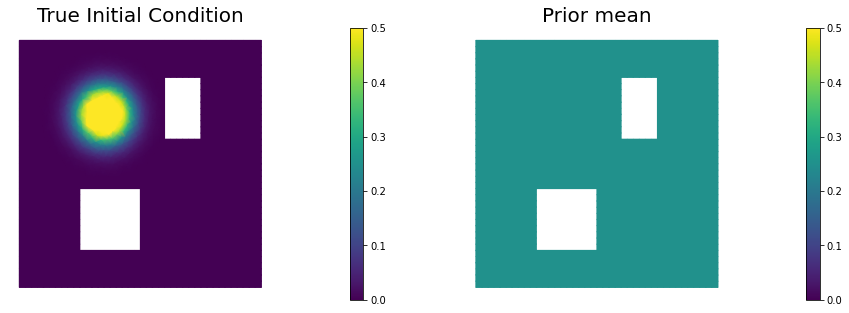

In [9]:
objs = [dl.Function(Vh,true_initial_condition),
        dl.Function(Vh,prior.mean)]
mytitles = ["True Initial Condition", "Prior mean"]
nb.multi1_plot(objs, mytitles)
plt.show()

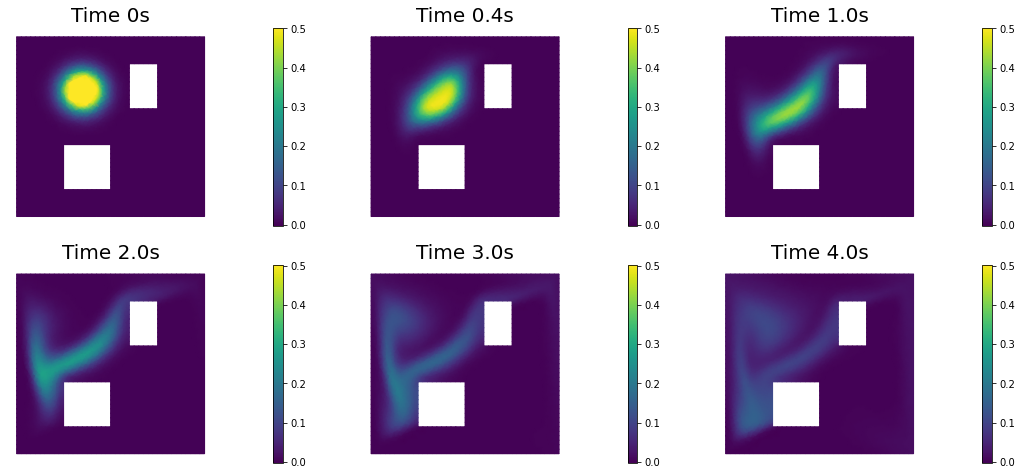

In [10]:
problem_true = TimeDependentAD(mesh, [Vh,Vh,Vh], prior, misfit, simulation_times, kappa_true, wind_velocity, True)
# relative noise level
rel_noise = 0.01

# initialize vector in the state space
utrue = problem_true.generate_vector(STATE)
x = [utrue, true_initial_condition, None]
# solve forward problem
problem_true.solveFwd(x[STATE], x)
# observe solution and add error
misfit.observe(x, misfit.d)
MAX = misfit.d.norm("linf", "linf")
noise_std_dev = rel_noise * MAX
parRandom.normal_perturb(noise_std_dev,misfit.d)

misfit.noise_variance = noise_std_dev*noise_std_dev

# plot solution
nb.show_solution(Vh, true_initial_condition, utrue, "Solution")
plt.savefig("forward_solution.pdf",pad_inches=1)

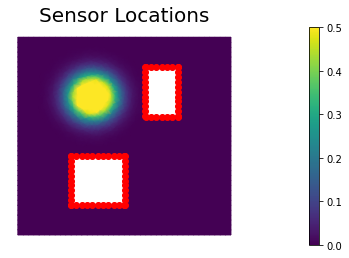

In [11]:
# plot target locations
nb.plot(dl.Function(Vh,true_initial_condition),mytitle='Sensor Locations')
plt.scatter(targets[:,0],targets[:,1],color='red')
# try with 1/4 as many sensors, maybe more noise

In [12]:
# Compare spectra of preconditioned vs unpreconditioned Hessian

# H = ReducedHessian(problem_true, misfit_only=True)
# k = 200
# p = 40
# Omega = MultiVector(x[PARAMETER], k+p)
# parRandom.normal(1., Omega)
# lmbda0, V0 = singlePassG(H, prior.R, prior.Rsolver, Omega, k)
# lmbda1, V1 = singlePass(H, Omega, k)

# plt.figure(figsize=(8,8))
# plt.rcParams.update({'font.size': 16})
# plt.semilogy(lmbda0,label='prior preconditioned')
# plt.semilogy(lmbda1,label='unpreconditioned')
# plt.ylabel('eigenvalue')
# plt.legend()

In [13]:
# this function has not been updated since before adding gamma, delta
def ComputePosterior(mesh, Vh, gamma, delta, misfit, simulation_times, kappa, wind_velocity):
    prior = BiLaplacianPrior(Vh, gamma, delta, robin_bc=True)
    prior.mean = dl.interpolate(dl.Constant(0.25), Vh).vector()
    
    problem = TimeDependentAD(mesh, [Vh,Vh,Vh], prior, misfit, simulation_times, kappa, wind_velocity, True)
    
    ## Compute the gradient
    [u,m,p] = problem.generate_vector()
    # forward solve
    problem.solveFwd(u, [u,m,p])
    # adjoint solve
    problem.solveAdj(p, [u,m,p])
    # initialize a vector in the parameter space
    mg = problem.generate_vector(PARAMETER)
    # evaluate gradient and store in mg
    grad_norm = problem.evalGradientParameter([u,m,p], mg)
    
    ## Compute posterior precision
    # matrix free application of posterior precision/covariance
    H = ReducedHessian(problem, misfit_only=True)
    
    # finds eigenvalues/vectors of H*x = lambda*R*x
    #k = 120
    k = 200
    p = 40
    Omega = MultiVector(x[PARAMETER], k+p)
    parRandom.normal(1., Omega)
    lmbda, V = singlePassG(H, prior.R, prior.Rsolver, Omega, k)

    posterior = GaussianLRPosterior(prior, lmbda, V, True)
    
    ## Compute posterior mean
    H.misfit_only = False
    solver = CGSolverSteihaug()
    solver.set_operator(H)
    solver.set_preconditioner( posterior.Hlr )
    solver.parameters["print_level"] = -1
    solver.parameters["rel_tolerance"] = 1e-6
    solver.solve(m, -mg)
    problem.solveFwd(u, [u,m,p])
    posterior.mean = m
    
    return posterior,mg,lmbda,V

def ComputePosteriorUnprecon(lmbda, V, misfit, simulation_times, kappa, wind_velocity, gamma, delta):
    prior = BiLaplacianPrior(Vh, gamma, delta, robin_bc=True)
    prior.mean = dl.interpolate(dl.Constant(0.25), Vh).vector()
    
    problem = TimeDependentAD(mesh, [Vh,Vh,Vh], prior, misfit, simulation_times, kappa, wind_velocity, True)
    
    ## Compute the gradient
    [u,m,p] = problem.generate_vector()
    # forward solve
    problem.solveFwd(u, [u,m,p])
    # adjoint solve
    problem.solveAdj(p, [u,m,p]) # these last three lines don't use the prior and should be precomputed
    # initialize a vector in the parameter space
    mg = problem.generate_vector(PARAMETER)
    # evaluate gradient and store in mg
    grad_norm = problem.evalGradientParameter([u,m,p], mg) # this involves the prior so we should compute it here
    
    ## Compute posterior precision
    # matrix free application of posterior precision/covariance
    H = ReducedHessian(problem, misfit_only=True)  # shouldn't need to do this, just use lmbda, V and add the prior
    
    posterior = GaussianLRPosterior(prior, lmbda, V, False)

#     Compute posterior mean
    H.misfit_only = False
    solver = CGSolverSteihaug()
    solver.set_operator(H) # use lmbda, V plus the prior here
    solver.set_preconditioner( posterior.Hlr )
    solver.parameters["print_level"] = -1
    solver.parameters["rel_tolerance"] = 1e-6
    solver.solve(m, -mg)
    problem.solveFwd(u, [u,m,p])
    posterior.mean = m
    
#     H = posterior.Hlr
#     H.solve(m,-mg)
#     posterior.mean = m

#     nb.plot(dl.Function(Vh,m))
    
    return posterior,mg

In [14]:
# prior precision of kappa -- normal centered at -2, stdev = 3 (log values)
q_kappa = 1/3
# prior mean of kappa
mu_kappa = -2

# # prior precision and mean of gamma and delta
# q_g = 1/2
# q_d = 1/2
# mu_g = 5
# mu_d = 5

# hyperprior parameters
alpha_del = 1
alpha_gam = 1
beta_del = 1e-4
beta_gam = 1e-4

In [15]:
# -log pi(kappa | u_d) (- log posterior marginal pdf of kappa)
def neglogpi_kappa(kappa):
    # compute new posterior
    gamma = 1.
    delta = 8.
    posterior,mg,lmbda,V = ComputePosterior(mesh, Vh, gamma, delta, misfit, simulation_times, kappa, wind_velocity)
    # -log(|Q_u_0|/|Q_u_0^\ast|)
    det_ratio = 0.0
    for ll in posterior.d:
        det_ratio += np.log(1+ll)
    # -log pdf of kappa prior
    kappa_prior = 0.5*(q_kappa**2)*(np.log10(kappa)-mu_kappa)**2
    # u_0^\ast^T Q_u_0^\ast u_0^\ast
    #uQu = - 0.5*posterior.Hlr.inner(posterior.mean,posterior.mean) # does unnecessary work + introduces error
    uQu = 0.5*mg.inner(posterior.mean)
    return det_ratio + kappa_prior + uQu

# -log pi(gamma, delta | u_d) (- log posterior marginal joint pdf of gamma, delta)
def neglogpi_gamma_delta(lmbda, V, kappa, gamma, delta):
    # compute new posterior
    #posterior,mg,lmbda,V = ComputePosterior(mesh, Vh, gamma, delta, misfit, simulation_times, kappa, wind_velocity)
    posterior,mg = ComputePosteriorUnprecon(lmbda, V, misfit, simulation_times, kappa, wind_velocity, gamma, delta)
    # -log(|Q_u_0|/|Q_u_0^\ast|)
    # Bhelp = Q_u0^-1 * V
    Bhelp = MultiVector(V)
    for i in range(V.nvec()):
        posterior.prior.Rsolver.solve(Bhelp[i],V[i])
    # B = diag(lmbda) * V^T Q_u0^-1 V + I
    B = V.dot_mv(Bhelp)
    for i in range(B.shape[0]):
        B[i,:] *= lmbda[i]
        B[i,i] += 1.
    Bvals = np.linalg.eigvals(B)
    # det_ratio = np.sum(np.log(Bvals))
    det_ratio = np.sum(np.log(Bvals)) - (alpha_del-1)*np.log(delta) - (alpha_gam-1)*np.log(gamma)
    # -log pdf of gamma, delta prior
    # gamma_delta_prior = 0.5*(q_g**2)*(gamma-mu_g)**2 + 0.5*(q_d**2)*(delta-mu_d)**2
    gamma_delta_prior = beta_del*delta + beta_gam*gamma
    kappa_prior = 0.5*(q_kappa**2)*(np.log10(kappa)-mu_kappa)**2
    # u_0^\ast^T Q_u_0^\ast u_0^\ast
    #uQu = - 0.5*posterior.Hlr.inner(posterior.mean,posterior.mean) # does unnecessary work + introduces error
    uQu = 0.5*mg.inner(posterior.mean)
    # - mu_0 Q_u0 mu_0
    Qmu = dl.Vector(posterior.prior.R.mpi_comm())
    posterior.prior.init_vector(Qmu,0)
    posterior.prior.R.mult(posterior.prior.mean,Qmu)
    muQmu = 0.5*posterior.prior.mean.inner(Qmu)
    return det_ratio + gamma_delta_prior + kappa_prior + uQu + muQmu, det_ratio, gamma_delta_prior+kappa_prior, uQu, muQmu

In [16]:
# # posterior1,mg1 = ComputePosteriorUnprecon(lmbda, V, misfit, simulation_times, kappa, wind_velocity, 30, 1000)
# g1, d1  = 300, 100000
# posterior1 ,mg1 ,lmbda1 ,V1 = ComputePosterior(mesh, Vh, g1, d1, misfit, simulation_times, kappa_true, wind_velocity)
# posterior1_var,pr1,corr1 = posterior1.pointwise_variance(method="Exact")
# nb.plot(dl.Function(Vh,posterior1.mean),mytitle='Posterior mean, gam = {0}, del = {1}'.format(g1,d1))

In [17]:
# # posterior2,mg2 = ComputePosteriorUnprecon(lmbda, V, misfit, simulation_times, kappa, wind_velocity, 60, 2000)
# g2, d2 = 600,200000
# posterior2 ,mg2 ,lmbda2 ,V2 = ComputePosterior(mesh, Vh, g2, d2, misfit, simulation_times, kappa_true, wind_velocity)
# posterior2_var,pr2,corr2 = posterior2.pointwise_variance(method="Exact")
# nb.plot(dl.Function(Vh,posterior2.mean),mytitle='Posterior mean, gam = {0}, del = {1}'.format(g2,d2))

In [18]:
# nb.plot(dl.Function(Vh,posterior1_var),mytitle='Posterior var, gam = {0}, del = {1}'.format(g1,d1))

In [19]:
# nb.plot(dl.Function(Vh,posterior2_var),mytitle='Posterior var, gamma = {0}, delta = {1}'.format(g2,d2))

In [20]:
# nb.plot(dl.Function(Vh,pr1),mytitle='Prior var, gam = {0}, del = {1}'.format(g1,d1))

In [21]:
# nb.plot(dl.Function(Vh,pr2),mytitle='Prior var, gam = {0}, del = {1}'.format(g2,d2))

In [22]:
# posterior,mg = ComputePosteriorUnprecon(lmbda, V, misfit, simulation_times, kappa, wind_velocity, 0.5, 6)

In [23]:
dummy_prior = BiLaplacianPrior(Vh, 1., 8., robin_bc=True)
dummy_prior.mean = dl.interpolate(dl.Constant(0.25), Vh).vector()
kappa = 0.001
problem = TimeDependentAD(mesh, [Vh,Vh,Vh], dummy_prior, misfit, simulation_times, kappa, wind_velocity, True)
H_misfit_only = ReducedHessian(problem, misfit_only=True)
k = 200
pad = 40
Omega = MultiVector(x[PARAMETER], k+pad)
parRandom.normal(1., Omega)
lmbda, V = singlePass(H_misfit_only, Omega, k)
# Bhelp = MultiVector(V)

    
# ## Compute the gradient
# [u,m,p] = problem.generate_vector()
# # forward solve
# %lprun -f TimeDependentAD.solveFwd problem.solveFwd(u, [u,m,p])
# # adjoint solve
# problem.solveAdj(p, [u,m,p])
    
# %lprun -f LowRankHessianUnprecon.__init__ posterior = GaussianLRPosterior(dummy_prior, lmbda, V, False)
logpi_ijk,det_ijk,pri_ijk,uQu_ijk,muQmu_ijk = neglogpi_gamma_delta(lmbda, V, kappa, 0.5,6)
# %lprun -f _BilaplacianRsolver.solve dummy_prior.Rsolver.solve(Bhelp[0],V[0])

ValueError: math domain error

In [24]:
# plot -log pi for a range of gammas, deltas
# g_range = np.linspace(0.4,600,5) #was at 0.1-2 before switching to 1D problem
# d_range = np.linspace(20,200000,5) #was at 1-15 before switching to 1D problem
nn = 5
nk = 2
g_range = np.linspace(0.5,0.8,nn) #0.5 to 0.8
d_range = np.linspace(2,7.5,nn) #2 to 7.5
k_range = np.linspace(0.0007, 0.001, nk)
logpi = np.zeros((nn,nn,nk))
det_ratios = np.zeros((nn,nn,nk))
priors = np.zeros((nn,nn,nk))
uQus = np.zeros((nn,nn,nk))
muQmus = np.zeros((nn,nn,nk))
print('Progress in indices computed from (0,0,0) to ({0},{0},{1}):'.format(nn-1,nk-1))
for kk in range(nk):
    # compute unpreconditioned low rank decomposition
    precompute_start = time.time()
    
    dummy_prior = BiLaplacianPrior(Vh, 1., 8., robin_bc=True)
    dummy_prior.mean = dl.interpolate(dl.Constant(0.25), Vh).vector()
    kappa = k_range[kk]
    problem = TimeDependentAD(mesh, [Vh,Vh,Vh], dummy_prior, misfit, simulation_times, kappa, wind_velocity, True)
    H_misfit_only = ReducedHessian(problem, misfit_only=True)
    k = 200
    pad = 40
    Omega = MultiVector(x[PARAMETER], k+pad)
    parRandom.normal(1., Omega)
    lmbda, V = singlePass(H_misfit_only, Omega, k)
#     [u,m,p] = problem.generate_vector()
#     problem.solveFwd(u, [u,m,p])
#     problem.solveAdj(p, [u,m,p])
    
    precompute_end = time.time()
    print(f"Precompute time: {precompute_end-precompute_start} seconds")
    for i in range(nn):
        for j in range(nn):
            logpi_ijk,det_ijk,pri_ijk,uQu_ijk,muQmu_ijk = neglogpi_gamma_delta(lmbda, V, kappa, g_range[i],d_range[j])
            logpi[i,j,kk] = logpi_ijk
            det_ratios[i,j,kk] = det_ijk
            priors[i,j,kk] = pri_ijk
            uQus[i,j,kk] = uQu_ijk
            muQmus[i,j,kk] = muQmu_ijk
            print('({0},{1},{2})'.format(i,j,kk))
    compute_end = time.time()
    print(f"Compute time: {compute_end-precompute_end} seconds")


Progress in indices computed from (0,0,0) to (4,4,1):
Precompute time: 6.737316131591797 seconds


ValueError: math domain error

Text(0.5, 0, '$\\delta$')

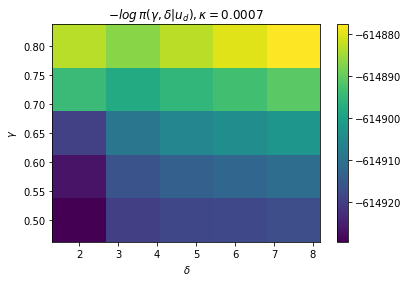

In [38]:
kk = 0
plt.pcolormesh(d_range,g_range,logpi[:,:,kk])
plt.colorbar()
plt.title(r'$-log \, \pi(\gamma, \delta | u_d),\kappa={0}$'.format(k_range[kk]))
plt.ylabel(r'$\gamma$')
plt.xlabel(r'$\delta$')

Text(0.5, 0, '$\\delta$')

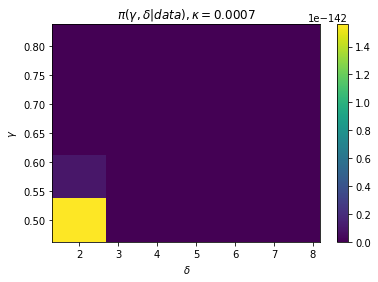

In [39]:
# scaled arbitrarily to have max value 1 in order to avoid overflow errors
kk = 0
plt.pcolormesh(d_range,g_range,np.exp(-logpi[:,:,kk]+np.min(logpi)))
plt.colorbar()
plt.title(r'$\pi(\gamma, \delta | data),\kappa={0}$'.format(k_range[kk]))
plt.ylabel(r'$\gamma$')
plt.xlabel(r'$\delta$')

Text(0.5, 0, '$\\delta$')

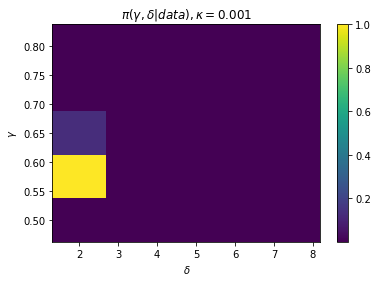

In [40]:
# scaled arbitrarily to have max value 1 in order to avoid overflow errors
kk = 1
plt.pcolormesh(d_range,g_range,np.exp(-logpi[:,:,kk]+np.min(logpi)))
plt.colorbar()
plt.title(r'$\pi(\gamma, \delta | data),\kappa={0}$'.format(k_range[kk]))
plt.ylabel(r'$\gamma$')
plt.xlabel(r'$\delta$')

In [42]:
logpi

array([[[-614929.40540605, -615248.90133987],
        [-614919.91994778, -615240.18296854],
        [-614918.50924275, -615240.53315804],
        [-614918.28621631, -615240.12566733],
        [-614917.23345175, -615239.48644607]],

       [[-614926.61975259, -615255.92834401],
        [-614916.2414932 , -615245.47388537],
        [-614913.83878036, -615245.05575096],
        [-614912.57293166, -615244.43709485],
        [-614911.1271146 , -615243.33133001]],

       [[-614919.43240394, -615253.87135178],
        [-614909.18740794, -615248.44195108],
        [-614905.7993763 , -615246.48131425],
        [-614904.39366729, -615244.52914282],
        [-614902.29411348, -615243.53261295]],

       [[-614894.46067592, -615240.96627017],
        [-614898.07331599, -615245.99304645],
        [-614895.50755668, -615243.47403226],
        [-614893.35779988, -615241.74766068],
        [-614891.01777249, -615240.54471449]],

       [[-614883.42014221, -615238.3320253 ],
        [-614886.99521314,